In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# Create data
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
from itertools import product
from utils.save_load import load
def find_level(s):
    for level in ['high', 'medium', 'low']:
        if level in s:
            return level
            
def load_client_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_acc.pt"))

def load_client_size(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_size.pt"))

def load_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))


def load_acc(exp, cs=False):
    c = load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_acc.pt"))
    if c[0] == 0:
        return c[1:]
    else:
        return c

def load_real_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "time.pt"))

def load_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.time"))

def load_ms(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_size.pt"))

def load_fed_avg_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_acc.pt"))

def load_fed_avg_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_loss.pt"))

def load_model_G(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_G.pt"))

def load_list_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))

def load_list_client_density(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_density"))
    
def load_train_number(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.train_number"))


def get_acc_time(acc,time):
    target_acc = [0.83]
    n = 20
    cv_acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
        # 创建一个字典来存储每个阈值的第一次超过的索引
    exceedances = {threshold: None for threshold in target_acc}
    ac_time = [None]*3
    i = 0
    # 遍历序列，检查每个元素是否超过任何未标记的阈值
    for index, value in enumerate(cv_acc):
        for threshold in target_acc:
            # 如果当前值大于阈值，并且这个阈值还没有找到超过的位置
            if value > threshold and exceedances[threshold] is None:
                exceedances[threshold] = int(cv_time[index])
                ac_time[i] = int(cv_time[index])
                i = i+1
    return ac_time



# 自定义格式化函数，将 x 轴单位改为 10^3
def format_kilo(x, _):
    return f"{int(x / 10000)}"
def plt_photo_acc(exp, exp_legend, fig_name='PR-FL', y_lim=[0.70, 0.90], x_lim=[1, 80000], cov = False):
    import matplotlib.pyplot as plt
    import os
    from os.path import join
    
    # Define the interval for markers
    interval = 50  # You can adjust this value to change the marker density
    # config2 = type("Config", (object,), {"EXP_NAME": "experiment_name"})  # 示例配置
    

    # Create a new figure
    figsize = (7, 5.25)
    plt.figure(figsize=figsize)
    ac_time = {}
    time = None
    from matplotlib.ticker import FuncFormatter
    # Iterate through all experiments to plot each curve
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            acc = load_acc(exp_name)
            # acc = load_fed_avg_acc(exp_name)
            fed_avg_acc = load_fed_avg_acc(exp_name)
            if  np.mean(acc[-100:-1])>np.mean(fed_avg_acc[-100:-1]):
                fed_avg_acc = acc
            else:
                fed_avg_acc = fed_avg_acc
            if 'fjord' in exp_name or 'heterofl' in exp_name or  'fedrolex' in exp_name:
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
            else:
                time = load_time(exp_name)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
                
            cv_acc = np.convolve(fed_avg_acc, np.ones((n,)) / n, mode='valid')
            cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
            if not cov: 
                cv_acc = fed_avg_acc
                cv_time = time
            # if 'fed_avg' in exp_name and 'mask_fed_avg' not in exp_name:
            #    interval = int(interval / 2)
            plt.plot(cv_time, cv_acc, linestyle=linestyles[i ], color=colors[i], linewidth=1, label=exp_legend[i],marker=markers[i],markevery=interval)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    # for key in ac_time.keys():
    #     print(key, ":", ac_time[key])
    # Set labels and axis limits
    plt.xlabel("Time ($10^4$ s)",fontsize=16)
    plt.ylabel("Test Accuracy",fontsize=16)
    plt.xticks(fontsize=14)  # 增大 x 轴刻度字体
    plt.yticks(fontsize=14)  # 增大 y 轴刻度字体
    plt.xlim(x_lim)
    plt.ylim(y_lim)
    # 使用 FuncFormatter 应用自定义格式
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo))
    # Add legend
    # Add legend
    plt.legend(
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1, 0),
        fontsize= 'x-large',
        ncol=2
    )

    # Set grid
    plt.grid(linestyle="--", color='black', lw=0.5, alpha=0.5)

    # Ensure result directories exist and save the figure
    result_path = join("results", config.EXP_NAME)
    fig_path = join(result_path, "figs")

    if not os.path.isdir(fig_path):
        os.makedirs(fig_path)

    plt.savefig(join(fig_path, fig_name + ".png"), dpi=600, bbox_inches='tight')  # Save as PNG format
    plt.show()

def get_time_acc(acc,time,time_line):
    windows = 5
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)


    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100

    return [time_line,round(b_mean, 2),f"{b_std:.2g}"]

def plt_time_acc(exp, time_line, acc_type='avg'):
    time_acc = {}
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_fed_avg_acc(exp_name)
            acc = load_acc(exp_name)
            # if  np.mean(acc[-100:-1])>np.mean(fed_avg_acc[-100:-1]):
            #     fed_avg_acc = acc
            # else:
            #     fed_avg_acc = fed_avg_acc
            fed_avg_acc = np.maximum(fed_avg_acc, acc)
            if 'fjord' in exp_name or 'heterofl' in exp_name or  'fedrolex' in exp_name:
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
            else:
                time = load_time(exp_name)
            time_acc[exp_name] = get_time_acc(fed_avg_acc,time,time_line)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    import pandas as pd
    import os
    from openpyxl import load_workbook
    for k, v in time_acc.items():
        print(k,v)
    file_path = config.EXP_NAME+'.xlsx'
    sheet_name = 'Sheet1'
    
    # 构造你的数据（你已有的 time_acc）
    df_new = pd.DataFrame([
        {
            'Name': k,
            'Time': v[0],
            'Accuracy': v[1],
            'Std': float(v[2]) if isinstance(v[2], str) else v[2]
        }
        for k, v in time_acc.items()
    ])
    
    # 如果文件存在，读取旧数据；否则创建空DataFrame
    if os.path.exists(file_path):
        df_old = pd.read_excel(file_path, sheet_name=sheet_name)
        df_combined = pd.concat([df_old, df_new], ignore_index=True)
    
        # 以追加模式打开并替换已有 sheet
        with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            df_combined.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        # 如果文件不存在，直接写入新数据
        df_new.to_excel(file_path, index=False)

        
dataset_name = "CIFAR10"
import configs.cifar10 as config
client_sel = False
time_lim = (-1000, 60000)
acc_lim = (0.0, 0.9)
lottery_ticket_acc_lim = (0.7, 0.9)
n = 20

result_path = join("results", config.EXP_NAME)
if not os.path.isdir(f"results/{config.EXP_NAME}/figs"):
    os.makedirs(f"results/{config.EXP_NAME}/figs")
fig_path = join(result_path, "figs")
linestyles = [(0, (2, 2)),'-', '--', '-.', ':', (0, (5, 1)), (0, (3, 5, 1, 5)), ]
colors     = ['red','blue', 'green', 'purple', 'orange', 'brown', 'pink']  # 第7个 red = 你的方法
markers    = [ '^','o', '*', 'D', 's', 'p', 'v',]  # 第7个 '^' = 你的方法


In [6]:
import os
result_path = join("results", config.EXP_NAME)
list = os.listdir(result_path)
list = sorted(list)


iid_2.0_high_pr_fl_Cifar10_2 [180000, 84.88, '0.24']
iid_25_2.0_high_pr_fl_Cifar10_1 [180000, 83.68, '0.19']
iid_25_2.0_high_pr_fl_Cifar10_2 [180000, 83.68, '0.17']
iid_25_2.0_high_pr_fl_Cifar10_3 [180000, 84.04, '0.15']
iid_25_2.0_high_pr_fl_Cifar10_4 [180000, 83.5, '0.18']
iid_25_2.0_high_pr_fl_Cifar10 [180000, 84.07, '0.2']
iid_25_2.0_high_pr_fl_Cifar10_6 [180000, 83.42, '0.11']
iid_2.0_medium_pr_fl_Cifar10_1 [180000, 84.67, '0.27']
iid_25_2.0_medium_pr_fl_Cifar10_1 [180000, 84.52, '0.36']
iid_25_2.0_medium_pr_fl_Cifar10_2 [180000, 85.22, '0.23']
iid_25_2.0_medium_pr_fl_Cifar10_3 [180000, 84.65, '0.19']
iid_25_2.0_medium_pr_fl_Cifar10_4 [180000, 84.43, '0.16']
iid_25_2.0_medium_pr_fl_Cifar10 [180000, 84.29, '0.17']
iid_25_2.0_medium_pr_fl_Cifar10_6 [180000, 84.52, '0.21']
iid_2.0_low_pr_fl_Cifar10_1 [180000, 85.6, '0.21']
iid_25_2.0_low_pr_fl_Cifar10_1 [180000, 85.6, '0.18']
iid_25_2.0_low_pr_fl_Cifar10_2 [180000, 85.47, '0.17']
iid_25_2.0_low_pr_fl_Cifar10_3 [180000, 85.42, '0.12']

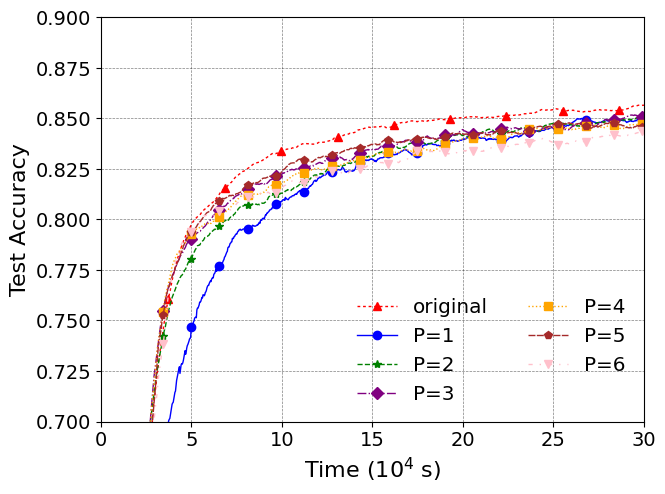

medium_iid


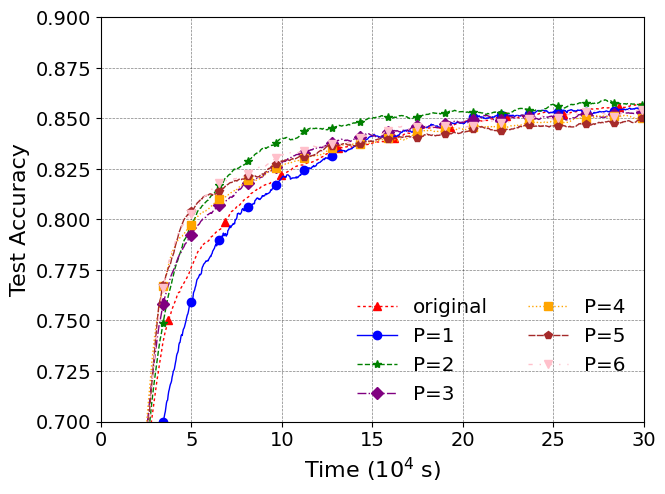

low_iid


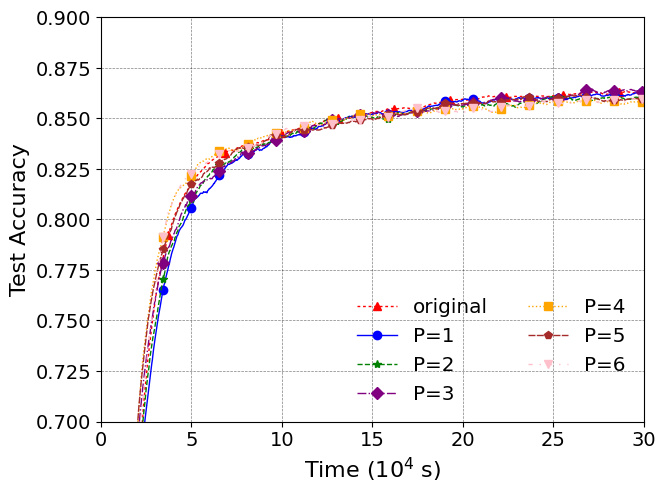

high_niid


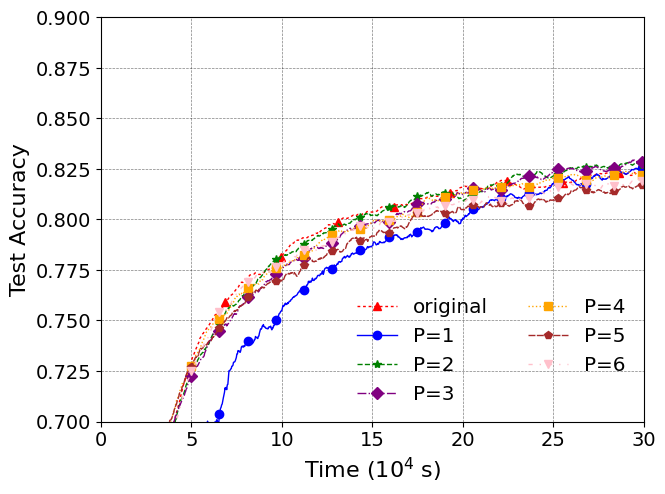

medium_niid


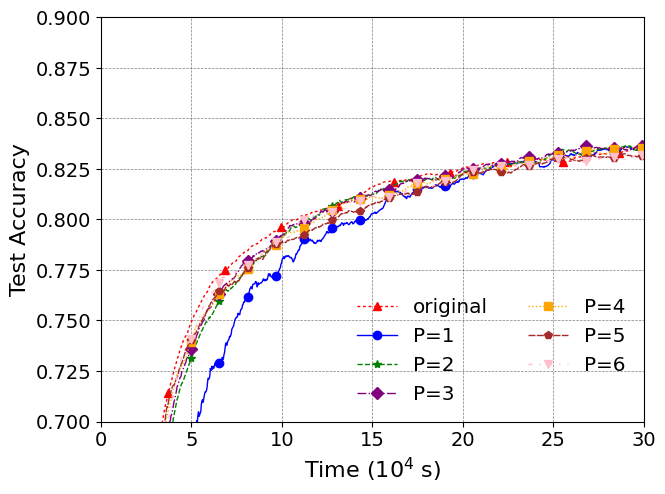

low_niid


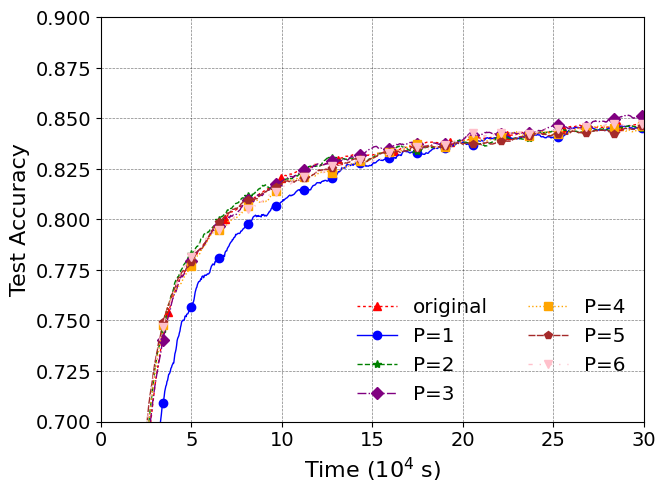

In [5]:


exp_list =[# ===== IID =====
    'iid_2.0_high_pr_fl_Cifar10_2',
 'iid_25_2.0_high_pr_fl_Cifar10_1',
 'iid_25_2.0_high_pr_fl_Cifar10_2',
 'iid_25_2.0_high_pr_fl_Cifar10_3',
 'iid_25_2.0_high_pr_fl_Cifar10_4',
 'iid_25_2.0_high_pr_fl_Cifar10',
 'iid_25_2.0_high_pr_fl_Cifar10_6',

    'iid_2.0_medium_pr_fl_Cifar10_1',
 'iid_25_2.0_medium_pr_fl_Cifar10_1',
 'iid_25_2.0_medium_pr_fl_Cifar10_2',
 'iid_25_2.0_medium_pr_fl_Cifar10_3',
 'iid_25_2.0_medium_pr_fl_Cifar10_4',
 'iid_25_2.0_medium_pr_fl_Cifar10',
 'iid_25_2.0_medium_pr_fl_Cifar10_6',

      'iid_2.0_low_pr_fl_Cifar10_1',  
 'iid_25_2.0_low_pr_fl_Cifar10_1',
 'iid_25_2.0_low_pr_fl_Cifar10_2',
 'iid_25_2.0_low_pr_fl_Cifar10_3',
 'iid_25_2.0_low_pr_fl_Cifar10_4',
 'iid_25_2.0_low_pr_fl_Cifar10',
 'iid_25_2.0_low_pr_fl_Cifar10_6',



    'niid_2.0_high_pr_fl_Cifar10_2',
 'niid_25_2.0_high_pr_fl_Cifar10_1',
 'niid_25_2.0_high_pr_fl_Cifar10_2',
 'niid_25_2.0_high_pr_fl_Cifar10_3',
 'niid_25_2.0_high_pr_fl_Cifar10_4',
'niid_25_2.0_high_pr_fl_Cifar10',
 'niid_25_2.0_high_pr_fl_Cifar10_6',

'niid_2.0_medium_pr_fl_Cifar10_2', 
 'niid_25_2.0_medium_pr_fl_Cifar10_1',
 'niid_25_2.0_medium_pr_fl_Cifar10_2',
 'niid_25_2.0_medium_pr_fl_Cifar10_3',
 'niid_25_2.0_medium_pr_fl_Cifar10_4',
 'niid_25_2.0_medium_pr_fl_Cifar10',
 'niid_25_2.0_medium_pr_fl_Cifar10_6',

       'niid_2.0_low_pr_fl_Cifar10_2',     
 'niid_25_2.0_low_pr_fl_Cifar10_1',
 'niid_25_2.0_low_pr_fl_Cifar10_2',
 'niid_25_2.0_low_pr_fl_Cifar10_3',
 'niid_25_2.0_low_pr_fl_Cifar10_4',
 'niid_25_2.0_low_pr_fl_Cifar10',
 'niid_25_2.0_low_pr_fl_Cifar10_6',





    

]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['original',
    'P=1','P=2',
              'P=3',
              'P=4',
              'P=5',
              'P=6'
             ]

  
plt_time_acc(exp_list, 180000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.70,0.90],x_lim= [0,300000],cov=True)
    i= i+len(exp_legend)
    



high_iid
1
Skipping iid_high_fedrolex_FEMNIST_10NBP. Client selection = False.


/tmp/ipykernel_44770/2624197345.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


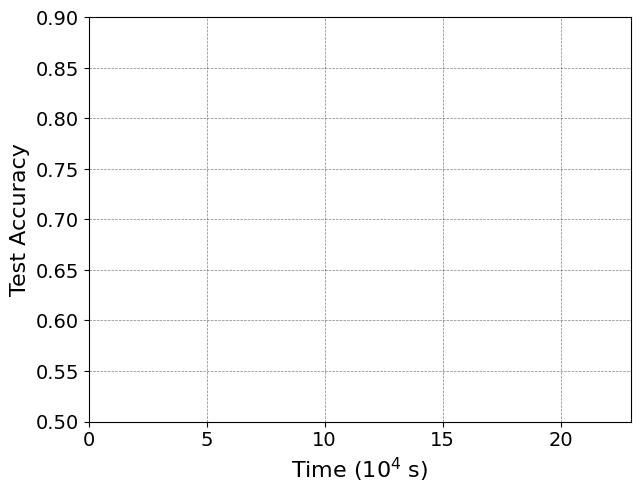

iid_2.0_high_pr_fl_Cifar10_2 [180000, 84.88, '0.24']
iid_high__fed_avg_Cifar10_5_5 [180000, 65.38, '0.78']
iid_high__fed_asyn_Cifar10_5_200_bp [180000, 83.17, '0.25']
iid_high_heterofl_Cifar10 [180000, 80.47, '0.19']
iid_high_fedrolex_Cifar10 [180000, 79.7, '0.22']
iid_high_fjord_Cifar10 [180000, 80.64, '0.21']
iid_high__fiarse_Cifar10_10_w_50_bp [180000, 69.73, '0.41']
iid_2.0_medium_pr_fl_Cifar10_2 [180000, 84.8, '0.1']
iid_medium__fed_avg_Cifar10_5_5 [180000, 65.75, '0.54']
iid_medium__fed_asyn_Cifar10_5_200_bp [180000, 84.06, '0.33']
iid_medium_heterofl_Cifar10 [180000, 80.44, '0.1']
iid_medium_fedrolex_Cifar10 [180000, 79.9, '0.14']
iid_medium_fjord_Cifar10 [180000, 80.77, '0.19']
iid_medium__fiarse_Cifar10_10_w_50_bp [180000, 69.72, '0.33']
iid_2.0_low_pr_fl_Cifar10_1 [180000, 85.6, '0.21']
iid_low__fed_avg_Cifar10_5_5 [180000, 66.14, '0.76']
iid_low__fed_asyn_Cifar10_5_200_bp [180000, 85.49, '0.25']
iid_low_heterofl_Cifar10 [180000, 79.59, '0.19']
iid_low_fedrolex_Cifar10 [18000

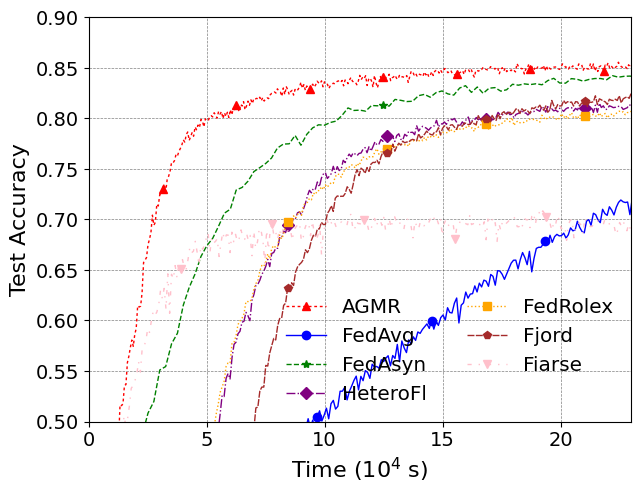

medium_iid


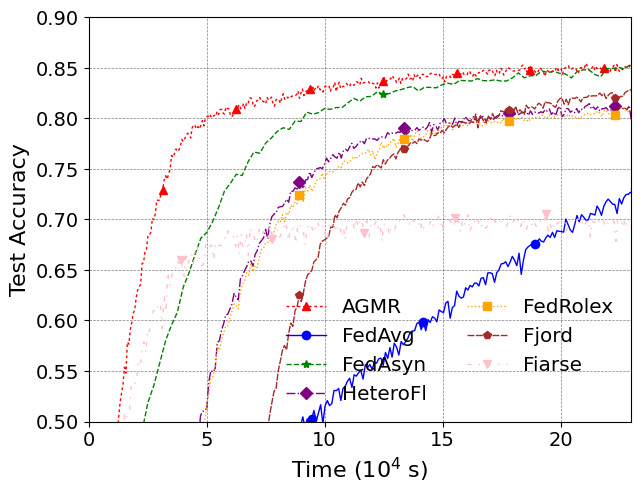

low_iid


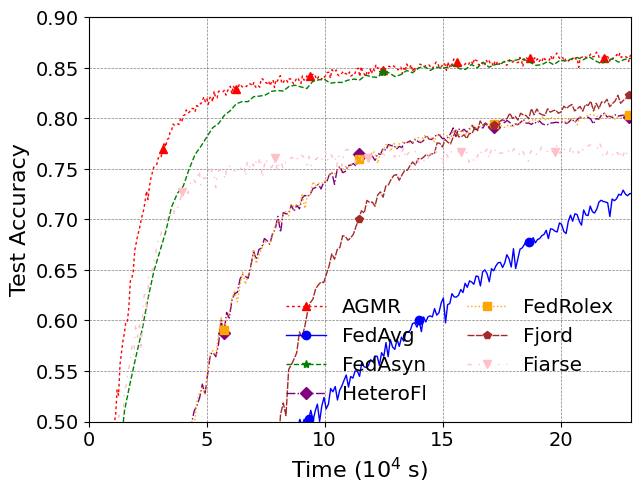

high_niid


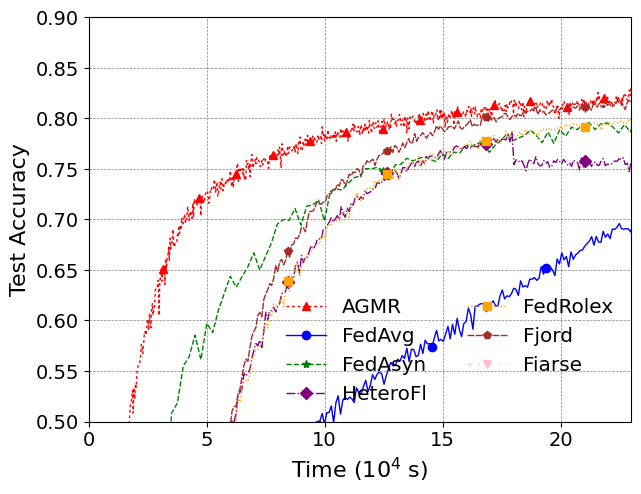

medium_niid


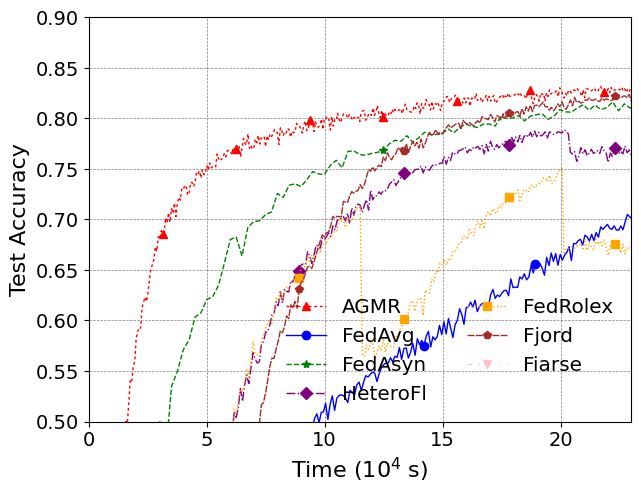

low_niid


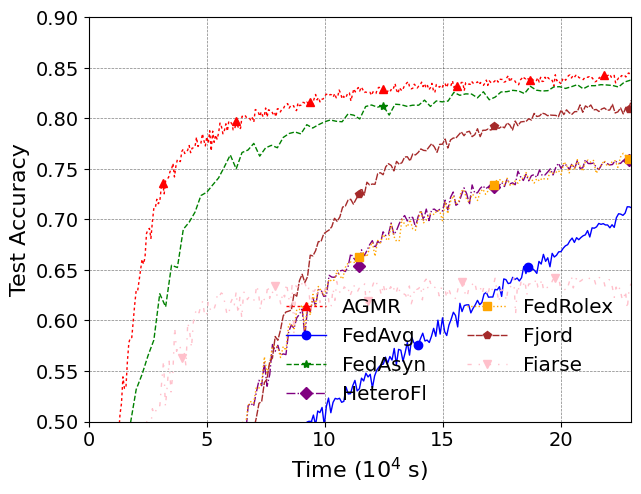

In [13]:
exp_list =[# ===== IID =====
'iid_2.0_high_pr_fl_Cifar10_2',
 'iid_high__fed_avg_Cifar10_5_5',
 'iid_high__fed_asyn_Cifar10_5_200_bp',
 'iid_high_heterofl_Cifar10',
 'iid_high_fedrolex_Cifar10',
 'iid_high_fjord_Cifar10',
 'iid_high__fiarse_Cifar10_10_w_50_bp',



'iid_2.0_medium_pr_fl_Cifar10_2',
 'iid_medium__fed_avg_Cifar10_5_5',
'iid_medium__fed_asyn_Cifar10_5_200_bp',
 'iid_medium_heterofl_Cifar10',
 'iid_medium_fedrolex_Cifar10',
 'iid_medium_fjord_Cifar10',
 'iid_medium__fiarse_Cifar10_10_w_50_bp',


'iid_2.0_low_pr_fl_Cifar10_1', 
 'iid_low__fed_avg_Cifar10_5_5',    
 'iid_low__fed_asyn_Cifar10_5_200_bp',
 'iid_low_heterofl_Cifar10',
 'iid_low_fedrolex_Cifar10',
 'iid_low_fjord_Cifar10',
 'iid_low__fiarse_Cifar10_10_w_50_bp',


 'niid_25_2.0_high_pr_fl_Cifar10_2',
 'niid_high__fed_avg_Cifar10_5_5',
 'niid_high__fed_asyn_Cifar10_5_200_bp',
 'niid_high_heterofl_Cifar10',
 'niid_high_fedrolex_Cifar10',
 'niid_high_fjord_Cifar10',
 'niid_high__fiarse_Cifar10_5_w_50_bp',


    
'niid_2.0_medium_pr_fl_Cifar10_2',
 'niid_medium__fed_avg_Cifar10_5_5',
'niid_medium__fed_asyn_Cifar10_5_200_bp',
 'niid_medium_heterofl_Cifar10',
 'niid_medium_fedrolex_Cifar10',
 'niid_medium_fjord_Cifar10',
'niid_medium__fiarse_Cifar10_10_w_50_bp',


 'niid_2.0_low_pr_fl_Cifar10_2',
 'niid_low__fed_avg_Cifar10_5_5',
 'niid_low__fed_asyn_Cifar10_5_200_bp',
 'niid_low_heterofl_Cifar10',
 'niid_low_fedrolex_Cifar10',
 'niid_low_fjord_Cifar10',
 'niid_low__fiarse_Cifar10_10_w_50_bp',


    

]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = [
 'AGMR',
     'FedAvg',
    'FedAsyn',
'HeteroFl',
'FedRolex',
'Fjord',
 'Fiarse',
]

  
# plt_time_acc(exp_list, 60000)
plt_time_acc(exp_list, 180000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn +'baseline'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.50,0.90],x_lim= [0,230000])
    i= i+len(exp_legend)
    



In [14]:
exp_list =[# ===== IID =====



'iid_2.0_high_pr_fl_Cifar10',
'iid_1.0_high_asyn_Cifar10',
'Ablation_iid_high__gmr_Cifar10_Re2__10_50_bp',
'iid_1.0_high_gradient_avg_Cifar10',
'iid_2.0_high_gradient_avg_Cifar10',
'iid_1.0_high_mask_fed_avg_Cifar10',
    

'iid_2.0_medium_pr_fl_Cifar10',
'iid_1.0_medium_asyn_Cifar10',
'Ablation_iid_medium__gmr_Cifar10_Re2__10_50_bp',
'iid_1.0_medium_gradient_avg_Cifar10',
'iid_2.0_medium_gradient_avg_Cifar10',
'iid_1.0_medium_mask_fed_avg_Cifar10',
    
'iid_2.0_low_pr_fl_Cifar10',
'iid_1.0_low_asyn_Cifar10',
'Ablation_iid_low__gmr_Cifar10_Re2__10_50_bp',
'iid_1.0_low_gradient_avg_Cifar10',
'iid_2.0_low_gradient_avg_Cifar10',
'iid_1.0_low_mask_fed_avg_Cifar10',
    

'niid_2.0_high_pr_fl_Cifar10',
'niid_1.0_high_asyn_Cifar10',
'Ablation_niid_high__gmr_Cifar10_Re2__10_50_bp',
'niid_1.0_high_gradient_avg_Cifar10',
'niid_2.0_high_gradient_avg_Cifar10',
'niid_1.0_high_mask_fed_avg_Cifar10',
    


'niid_2.0_medium_pr_fl_Cifar10',
'niid_1.0_medium_asyn_Cifar10',
'Ablation_niid_medium__gmr_Cifar10_Re2__10_50_bp',
'niid_1.0_medium_gradient_avg_Cifar10',
'niid_2.0_medium_gradient_avg_Cifar10',
'niid_1.0_medium_mask_fed_avg_Cifar10',

    

'niid_2.0_low_pr_fl_Cifar10',
 'niid_1.0_low_asyn_Cifar10',
 'Ablation_niid_low__gmr_Cifar10_Re2__10_50_bp',
 'niid_1.0_low_gradient_avg_Cifar10',
'niid_2.0_low_gradient_avg_Cifar10',
 'niid_1.0_low_mask_fed_avg_Cifar10',


    

]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['AGMR',
 '-Asyn',
 '-GMR',
 '-Gradientavg',
 '-Gradientavg2',
'-FedAvg']
plt_time_acc(exp_list, 9000)
# plt_time_acc(exp_list, 180000)
# i = 0 
# while i < len(exp_list):
#     exp = exp_list[i:i+len(exp_legend)]
#     fn = fig_name_list[int(i/len(exp_legend))]
#     print(fn)
#     fn = fn+'ablation'
#     plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.6,0.90],x_lim= [0,300000],cov=True)
#     i= i+len(exp_legend)
    
  


iid_2.0_high_pr_fl_Cifar10 [9000, 47.37, '4']
iid_1.0_high_asyn_Cifar10 [9000, 47.58, '3.9']
Ablation_iid_high__gmr_Cifar10_Re2__10_50_bp [9000, 47.44, '3.8']
iid_1.0_high_gradient_avg_Cifar10 [9000, 18.99, '5']
iid_2.0_high_gradient_avg_Cifar10 [9000, 18.91, '4.9']
iid_1.0_high_mask_fed_avg_Cifar10 [9000, 10.0, '0']
iid_2.0_medium_pr_fl_Cifar10 [9000, 46.51, '3.9']
iid_1.0_medium_asyn_Cifar10 [9000, 47.11, '3.9']
Ablation_iid_medium__gmr_Cifar10_Re2__10_50_bp [9000, 46.53, '3.8']
iid_1.0_medium_gradient_avg_Cifar10 [9000, 17.55, '5.3']
iid_2.0_medium_gradient_avg_Cifar10 [9000, 17.46, '5.4']
iid_1.0_medium_mask_fed_avg_Cifar10 [9000, 10.0, '0']
iid_2.0_low_pr_fl_Cifar10 [9000, 50.13, '4.4']
iid_1.0_low_asyn_Cifar10 [9000, 50.65, '3.9']
Ablation_iid_low__gmr_Cifar10_Re2__10_50_bp [9000, 50.21, '4.5']
iid_1.0_low_gradient_avg_Cifar10 [9000, 30.09, '3.5']
iid_2.0_low_gradient_avg_Cifar10 [9000, 29.96, '3.5']
iid_1.0_low_mask_fed_avg_Cifar10 [9000, 10.0, '0']
niid_2.0_high_pr_fl_Cifar10 [

iid_2.0_high_pr_fl_Cifar10_1 [150000, 83.18, '0.39']
iid_2.0_high_pr_fl_Cifar10_2 [150000, 84.69, '0.14']
iid_2.0_high_pr_fl_Cifar10 [150000, 83.64, '0.25']
iid_2.0_high_pr_fl_Cifar10_7 [150000, 83.6, '0.25']
iid_2.0_high_pr_fl_Cifar10_10 [150000, 83.51, '0.16']
iid_2.0_high_pr_fl_Cifar10_15 [150000, 82.92, '0.22']
iid_2.0_medium_pr_fl_Cifar10_1 [150000, 83.79, '0.26']
iid_2.0_medium_pr_fl_Cifar10_2 [150000, 84.16, '0.22']
iid_2.0_medium_pr_fl_Cifar10 [150000, 83.95, '0.16']
iid_2.0_medium_pr_fl_Cifar10_7 [150000, 84.12, '0.2']
iid_2.0_medium_pr_fl_Cifar10_10 [150000, 83.79, '0.2']
iid_2.0_medium_pr_fl_Cifar10_15 [150000, 84.24, '0.23']
iid_2.0_low_pr_fl_Cifar10_1 [150000, 85.25, '0.27']
iid_2.0_low_pr_fl_Cifar10_2 [150000, 85.26, '0.15']
iid_2.0_low_pr_fl_Cifar10 [150000, 85.26, '0.12']
iid_2.0_low_pr_fl_Cifar10_7 [150000, 85.17, '0.18']
iid_2.0_low_pr_fl_Cifar10_10 [150000, 85.29, '0.17']
iid_2.0_low_pr_fl_Cifar10_15 [150000, 85.31, '0.25']
niid_2.0_high_pr_fl_Cifar10_1 [150000, 79.1

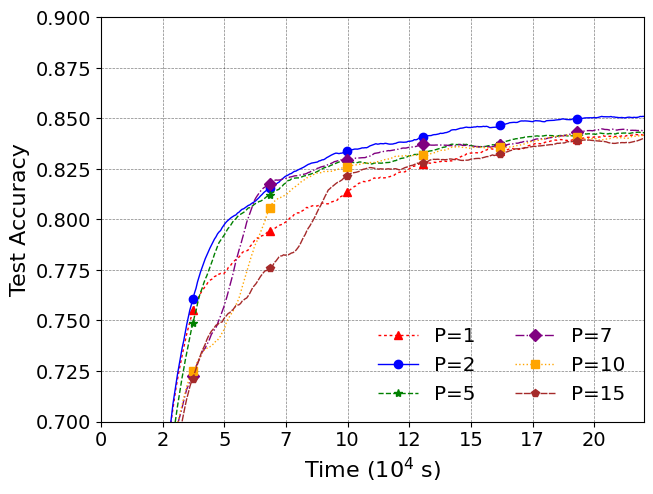

medium_iid


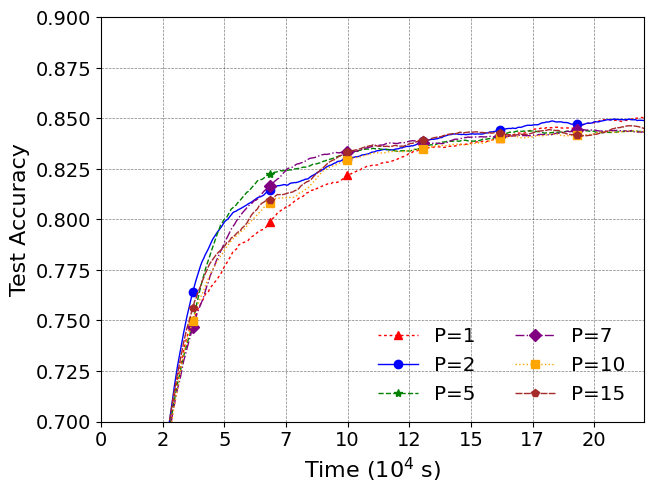

low_iid


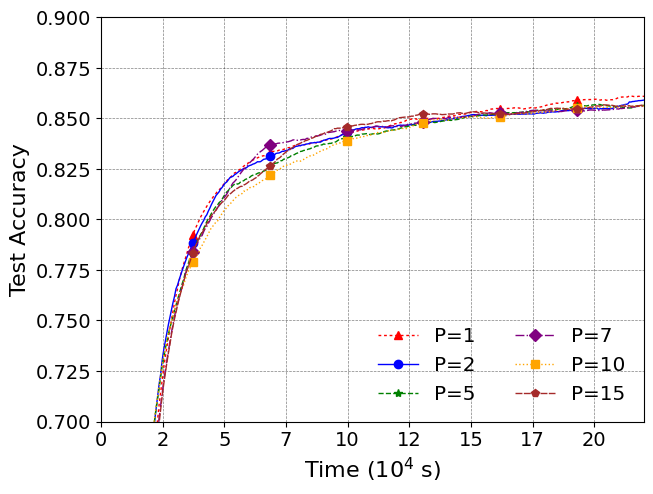

high_niid


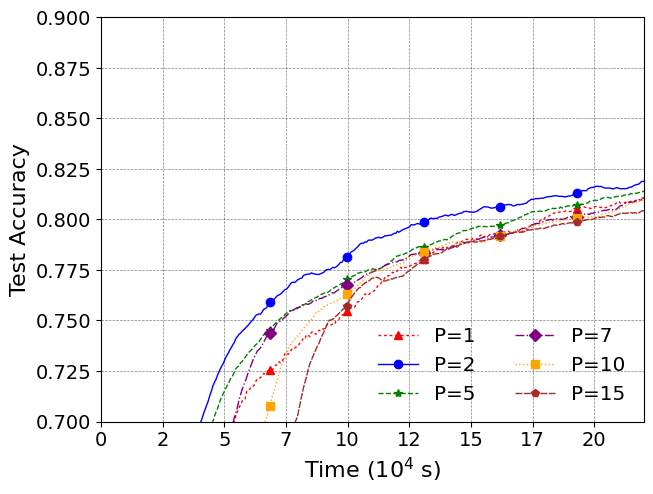

medium_niid


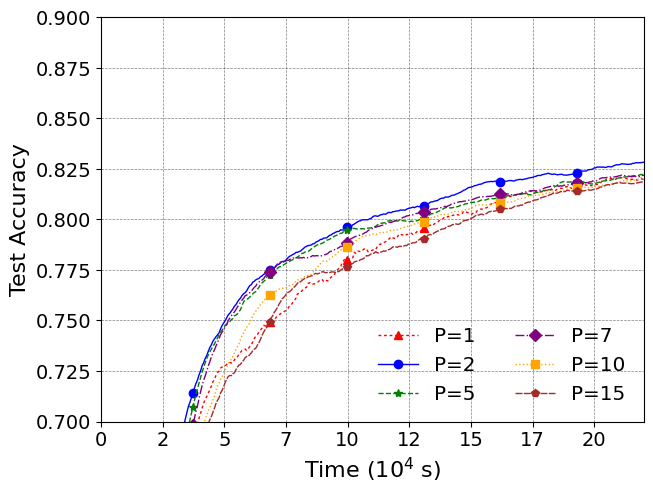

low_niid


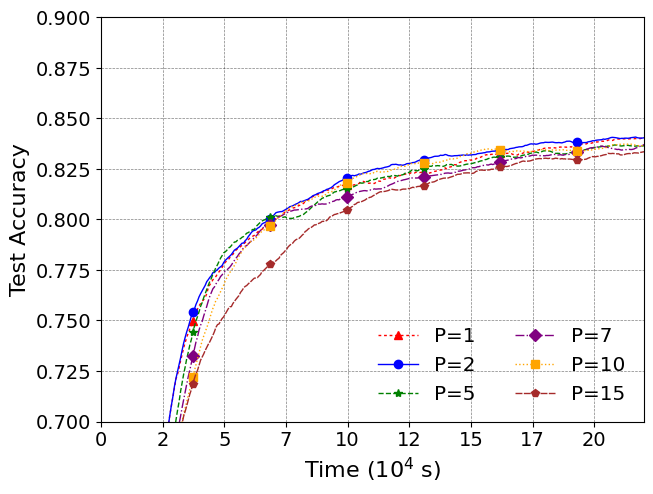

In [7]:
exp_list =[# ===== IID =====
 'iid_2.0_high_pr_fl_Cifar10_1',
 'iid_2.0_high_pr_fl_Cifar10_2',
 'iid_2.0_high_pr_fl_Cifar10',
 'iid_2.0_high_pr_fl_Cifar10_7',
 'iid_2.0_high_pr_fl_Cifar10_10',
 'iid_2.0_high_pr_fl_Cifar10_15',

'iid_2.0_medium_pr_fl_Cifar10_1',
 'iid_2.0_medium_pr_fl_Cifar10_2',
 'iid_2.0_medium_pr_fl_Cifar10',
 'iid_2.0_medium_pr_fl_Cifar10_7',
'iid_2.0_medium_pr_fl_Cifar10_10',
 'iid_2.0_medium_pr_fl_Cifar10_15',

    
 'iid_2.0_low_pr_fl_Cifar10_1',
 'iid_2.0_low_pr_fl_Cifar10_2',
 'iid_2.0_low_pr_fl_Cifar10',
 'iid_2.0_low_pr_fl_Cifar10_7',
 'iid_2.0_low_pr_fl_Cifar10_10',
 'iid_2.0_low_pr_fl_Cifar10_15',
    



 'niid_2.0_high_pr_fl_Cifar10_1',
 'niid_2.0_high_pr_fl_Cifar10_2',
 'niid_2.0_high_pr_fl_Cifar10',
 'niid_2.0_high_pr_fl_Cifar10_7',
 'niid_2.0_high_pr_fl_Cifar10_10',
 'niid_2.0_high_pr_fl_Cifar10_15',

    

 'niid_2.0_medium_pr_fl_Cifar10_1',
 'niid_2.0_medium_pr_fl_Cifar10_2',
 'niid_2.0_medium_pr_fl_Cifar10',
 'niid_2.0_medium_pr_fl_Cifar10_7',
'niid_2.0_medium_pr_fl_Cifar10_10',
 'niid_2.0_medium_pr_fl_Cifar10_15',


 'niid_2.0_low_pr_fl_Cifar10_1',
 'niid_2.0_low_pr_fl_Cifar10_2',
 'niid_2.0_low_pr_fl_Cifar10',
 'niid_2.0_low_pr_fl_Cifar10_7',
 'niid_2.0_low_pr_fl_Cifar10_10',
 'niid_2.0_low_pr_fl_Cifar10_15',
    
]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['P=1','P=2','P=5',
              'P=7','P=10',
              'P=15']

  
plt_time_acc(exp_list, 150000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.70,0.90],x_lim= [0,220000],cov = True)
    i= i+len(exp_legend)
    



Skipping iid_10_2.0_high_pr_fl_Cifar10_32. Client selection = False.
Skipping iid_10_2.0_low_pr_fl_Cifar10_32. Client selection = False.
Skipping niid_10_2.0_high_pr_fl_Cifar10_32. Client selection = False.
Skipping niid_10_2.0_medium_pr_fl_Cifar10_32. Client selection = False.
Skipping niid_10_2.0_low_pr_fl_Cifar10_32. Client selection = False.
iid_10_2.0_high_pr_fl_Cifar10_1 [150000, 82.43, '0.3']
iid_10_2.0_high_pr_fl_Cifar10_2 [150000, 82.72, '0.44']
iid_10_2.0_high_pr_fl_Cifar10_4 [150000, 82.67, '0.41']
iid_10_2.0_high_pr_fl_Cifar10_8 [150000, 82.85, '0.23']
iid_10_2.0_high_pr_fl_Cifar10_16 [150000, 83.18, '0.27']
iid_10_2.0_medium_pr_fl_Cifar10_1 [150000, 83.93, '0.3']
iid_10_2.0_medium_pr_fl_Cifar10_2 [150000, 83.84, '0.45']
iid_10_2.0_medium_pr_fl_Cifar10_4 [150000, 83.76, '0.34']
iid_10_2.0_medium_pr_fl_Cifar10_8 [150000, 83.96, '0.23']
iid_10_2.0_medium_pr_fl_Cifar10_16 [150000, 84.05, '0.22']
iid_10_2.0_medium_pr_fl_Cifar10_32 [150000, 83.76, '0.29']
iid_10_2.0_low_pr_fl_Ci

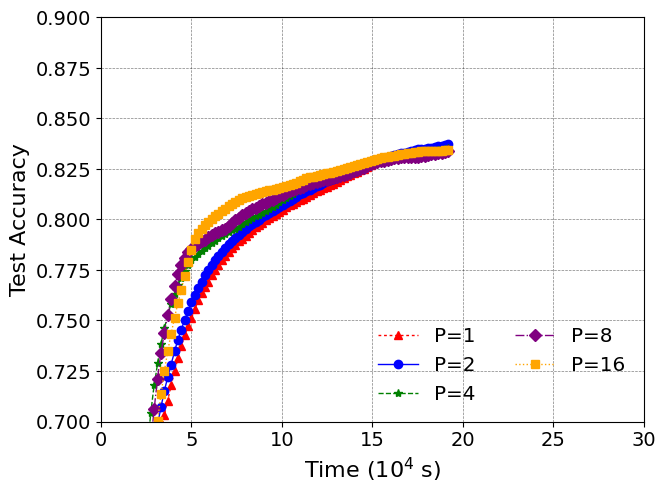

medium_iid


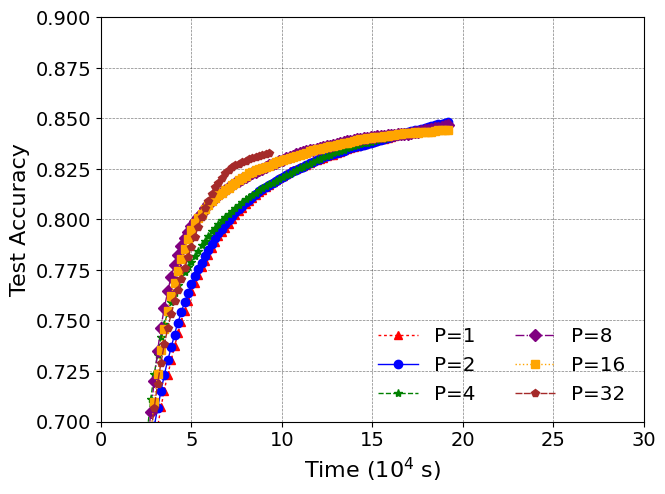

low_iid
Skipping iid_10_2.0_low_pr_fl_Cifar10_32. Client selection = False.


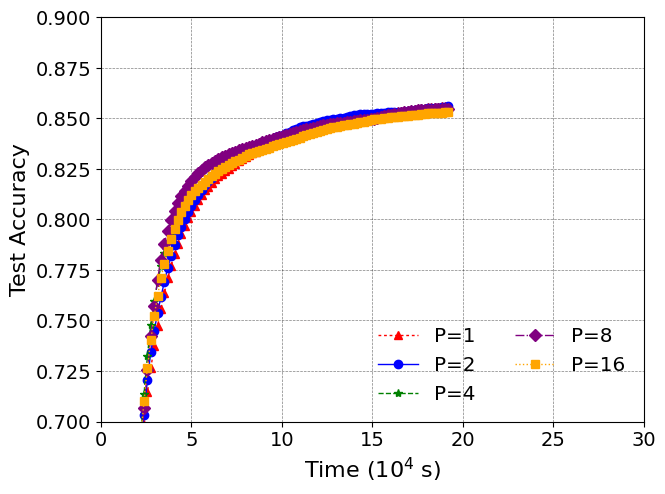

high_niid
Skipping niid_10_2.0_high_pr_fl_Cifar10_32. Client selection = False.


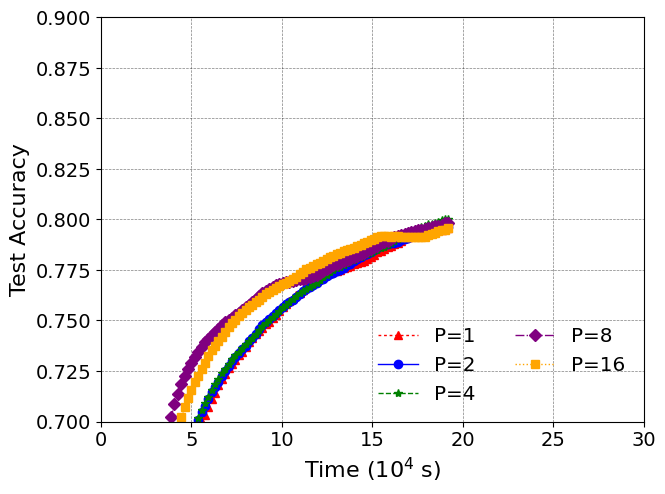

medium_niid
Skipping niid_10_2.0_medium_pr_fl_Cifar10_32. Client selection = False.


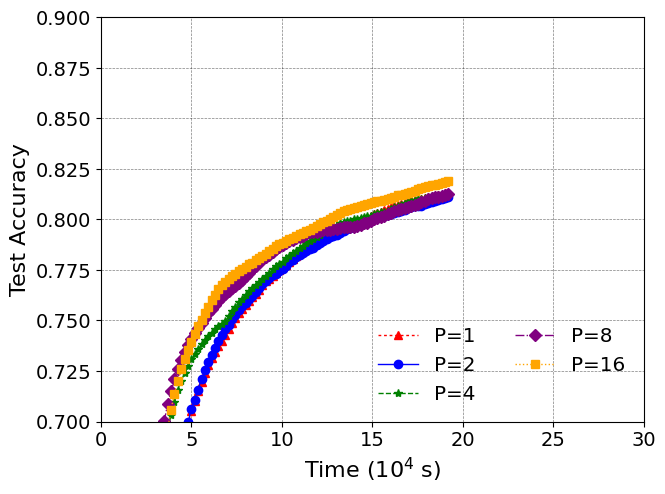

low_niid
Skipping niid_10_2.0_low_pr_fl_Cifar10_32. Client selection = False.


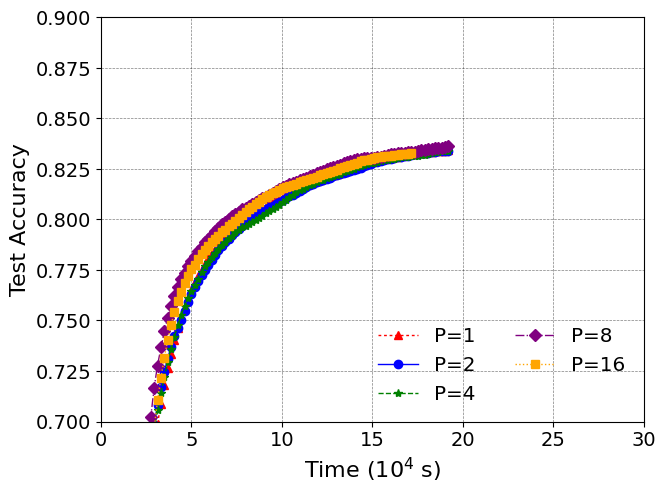

GMR_cifar10


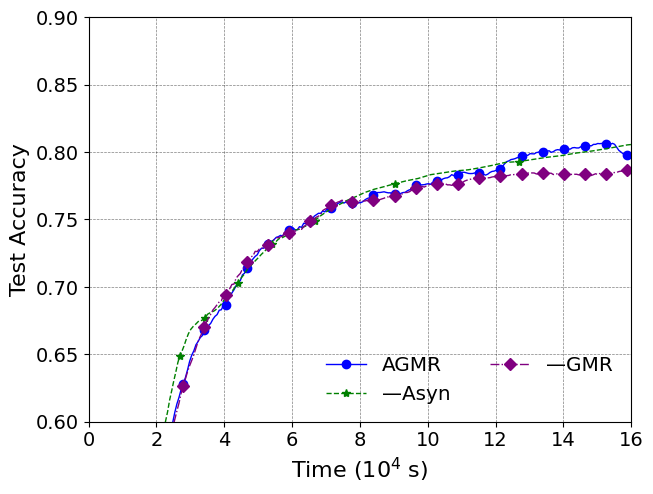

Skipping iid_low_asyn_Cifar10_clip. Client selection = False.
iid_medium_asyn_Cifar10_clip [60000, 79.46, '0.91']
iid_high_asyn_Cifar10_clip [60000, 79.4, '0.73']
niid_low_asyn_Cifar10_clip [60000, 75.39, '1.1']
niid_medium_asyn_Cifar10_clip [60000, 72.86, '1.6']
niid_high_asyn_Cifar10_clip [60000, 71.36, '1.2']
Skipping iid_low_asyn_Cifar10_clip. Client selection = False.
iid_medium_asyn_Cifar10_clip [200000, 84.35, '0.24']
iid_high_asyn_Cifar10_clip [200000, 84.22, '0.32']
niid_low_asyn_Cifar10_clip [200000, 81.89, '0.35']
niid_medium_asyn_Cifar10_clip [200000, 81.23, '0.61']
niid_high_asyn_Cifar10_clip [200000, 79.63, '0.61']
high_iid
Skipping iid_low_asyn_Cifar10_clip. Client selection = False.


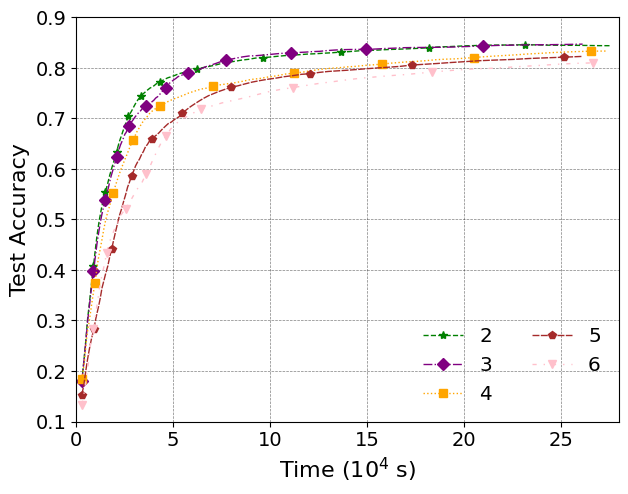

In [17]:
exp_list =[# ===== IID =====
'iid_low_asyn_Cifar10_clip',
'iid_medium_asyn_Cifar10_clip',
'iid_high_asyn_Cifar10_clip',
'niid_low_asyn_Cifar10_clip',
'niid_medium_asyn_Cifar10_clip',
'niid_high_asyn_Cifar10_clip',  
    

    



    

]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['1','2','3','4','5','6']

   
plt_time_acc(exp_list, 60000)
plt_time_acc(exp_list, 200000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.10,0.90],x_lim= [0,280000])
    i= i+len(exp_legend)
    



niid_low__1.0_10_pr_fl_Cifar10_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [60000, 81.25, '0.53']
niid_low__1.0_10_pr_fl_Cifar10_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [60000, 82.48, '0.72']
niid_low__1.0_10_pr_fl_Cifar10_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [60000, 82.3, '0.81']
niid_low__1.0_10_pr_fl_Cifar10_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [60000, 82.44, '0.58']
niid_low__1.0_10_pr_fl_Cifar10_25_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [60000, 83.36, '0.74']
niid_low__1.0_10_pr_fl_Cifar10_30_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [60000, 82.61, '0.89']
niid_low__1.0_10_pr_fl_Cifar10_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [200000, 84.9, '0.57']
niid_low__1.0_10_pr_fl_Cifar10_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [200000, 85.94, '0.54']
niid_low__1.0_10_pr_fl_Cifar10_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [200000, 85.33, '0.42']
niid_low__1.0_10_pr_fl_Cifar10_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [200000, 85.34, '0.41']
niid_low__1.0_10_pr_fl_Cifar10_25_[1.0, 0.5, 0.2, 0.1, 0.05]__50 [200000, 85.46, '0.56']
niid_low__1.0_10_pr_fl_Cifar10_

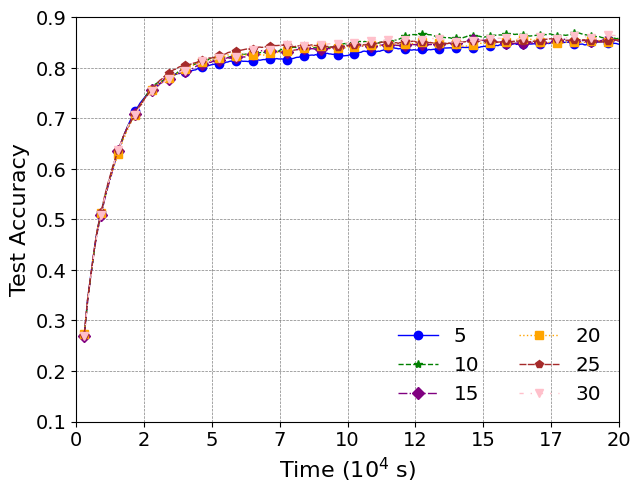

In [28]:
exp_list =[# ===== IID =====
'niid_low__1.0_10_pr_fl_Cifar10_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
'niid_low__1.0_10_pr_fl_Cifar10_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_Cifar10_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_Cifar10_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_Cifar10_25_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_Cifar10_30_[1.0, 0.5, 0.2, 0.1, 0.05]__50',


]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['5','10','15','20','25','30']

   
plt_time_acc(exp_list, 60000)
plt_time_acc(exp_list, 200000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.10,0.90],x_lim= [0,200000])
    i= i+len(exp_legend)
    

